<a href="https://colab.research.google.com/github/Lucas-O-S/N1B1-Regressao/blob/main/N1_Grupo_6_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Etapa 1 - Configuração do ambiente e carregamento dos dados


Confiração do ambiente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
urlDataset = "https://raw.githubusercontent.com/Lucas-O-S/N1B1-Regressao/refs/heads/main/train(in).csv"

Viridis é uma paleta de cores que vai usar nos graficos sem precisar ficar passando cor pra cada um deles display max column vai mostrar todas as colunas do dataframe quando utilizar print(df) sem reduzir o numero "..."

In [ ]:
sns.set_palette("viridis")
pd.set_option('display.max_columns', None)

criando uma variavel com numero 42 para garantir reprodutibilidade e o random seed vai gerar numeros aleatorios de NumPhy para embaralhar as linhas anted de dividir treinamento e teste

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ler o arquivo

In [ ]:
data = pd.read_csv(urlDataset)


# Etapa 2 - Análise exploratoria dos dados (EDA)

Pegar o numero de itens e numero de colunas, já o data info é um resume estrutural de cada coluna, verificar quantos valores não nulos tem, o tipo do dado.

In [ ]:
print(f"Formato do dataset: {data.shape[0]} linhas x {data.shape[1]} colunas")
data.info()

Formato do dataset: 1000 linhas x 12 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   v.id           1000 non-null   int64  
 1   on road old    1000 non-null   int64  
 2   on road now    1000 non-null   int64  
 3   years          1000 non-null   int64  
 4   km             1000 non-null   int64  
 5   rating         1000 non-null   int64  
 6   condition      1000 non-null   int64  
 7   economy        1000 non-null   int64  
 8   top speed      1000 non-null   int64  
 9   hp             1000 non-null   int64  
 10  torque         1000 non-null   int64  
 11  current price  1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


data.describe() mostra estatisticas resumidas de cada coluna numérica do DataFrame

In [ ]:
data.describe()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.00000
mean,500.500000,601648.286000,799131.3970,4.561000,100274.430000,2.988000,5.592000,11.625000,166.89300,84.54600,103.423000,308520.24250
std,288.819436,58407.246204,57028.9502,1.719079,29150.463233,1.402791,2.824449,2.230549,19.28838,20.51694,21.058716,126073.25915
min,1.000000,500265.000000,700018.0000,2.000000,50324.000000,1.000000,1.000000,8.000000,135.00000,50.00000,68.000000,28226.50000
25%,250.750000,548860.500000,750997.7500,3.000000,74367.500000,2.000000,3.000000,10.000000,150.00000,67.00000,85.000000,206871.75000
50%,500.500000,601568.000000,798168.0000,5.000000,100139.500000,3.000000,6.000000,12.000000,166.00000,84.00000,104.000000,306717.75000
75%,750.250000,652267.250000,847563.2500,6.000000,125048.000000,4.000000,8.000000,13.000000,184.00000,102.00000,121.000000,414260.87500
max,1000.000000,699859.000000,899797.0000,7.000000,149902.000000,5.000000,10.000000,15.000000,200.00000,120.00000,140.000000,584267.50000


Verificar se existem colunas com dado vazio se tiver mostra as colunas com problema, se não tiver vai aparecer nenhum valor encontrado e data.duplicated mostra se a linha é uma copia exata da anterior

In [ ]:
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado.")

print(f"Linhas duplicadas: {data.duplicated().sum()}")

Nenhum valor ausente encontrado.
Linhas duplicadas: 0


Gerar um histograma, o drop retira a coluna ou linha, neste caso, o v.id e devolve sem ela. já o frontsize e hist  quer pegar todas as colunas restante e desenha um histograma de cada um deles. O bins divide em intervalos de 30 faixas e conta quantas linhas caem em cada uma. Quanto mais bins mais detalhes, e menos tem uma vizão mais grosseira e suave. O figsizedefine o tamanho em polegadas largura e altura. Plt.suptitle adiciona o titulo geral e o plt.tight_layout não deixa as infos de sobrepoem e o show mostra as figuras

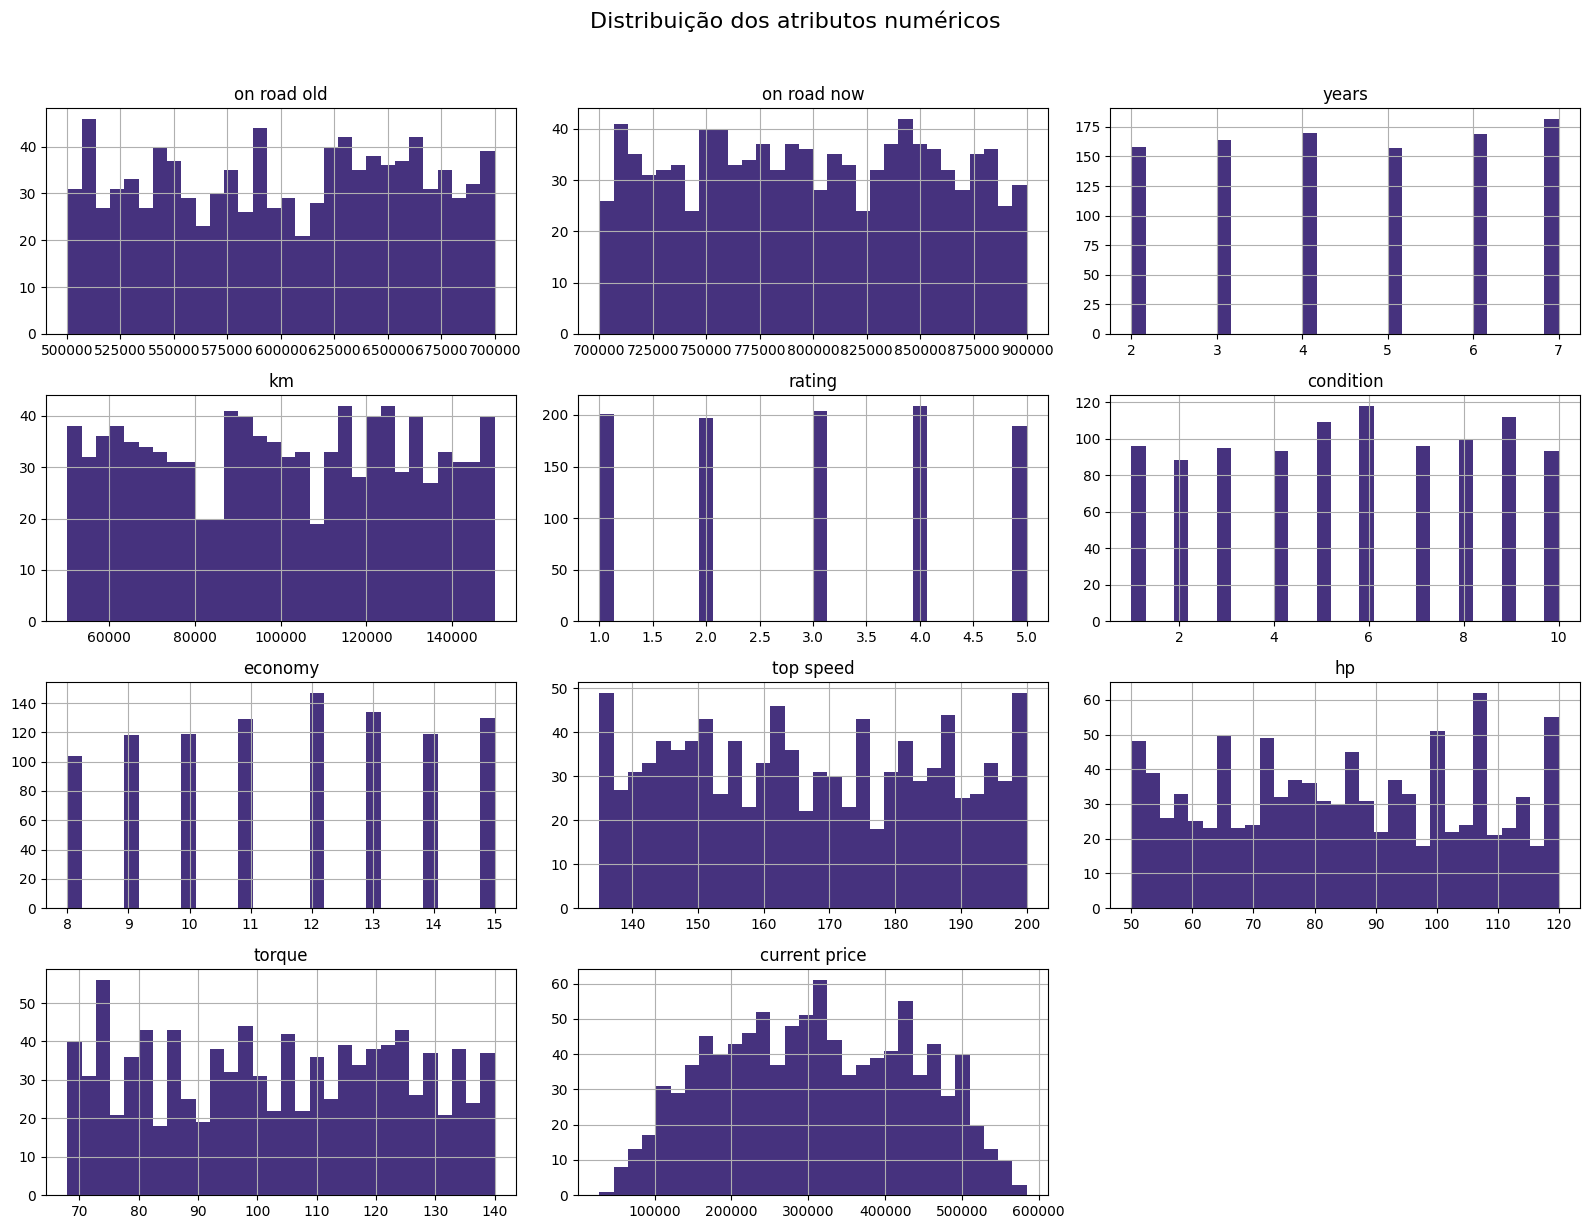

In [ ]:
data.drop(columns=['v.id']).hist(bins=30, figsize=(16, 12))
plt.suptitle("Distribuição dos atributos numéricos", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Todos parecem estar bem distribuidos

BOXPLOT para identificar outliers. De novo retirar o id e o preço agora. plt.subplots cria figura dividida. axes indica é 2D e figsize o tamanho da figura inteira. flatten achata tudo em uma lista simples com 10 eixos. Mostra o 1 quartil 25%, ao 3 quartil 75%

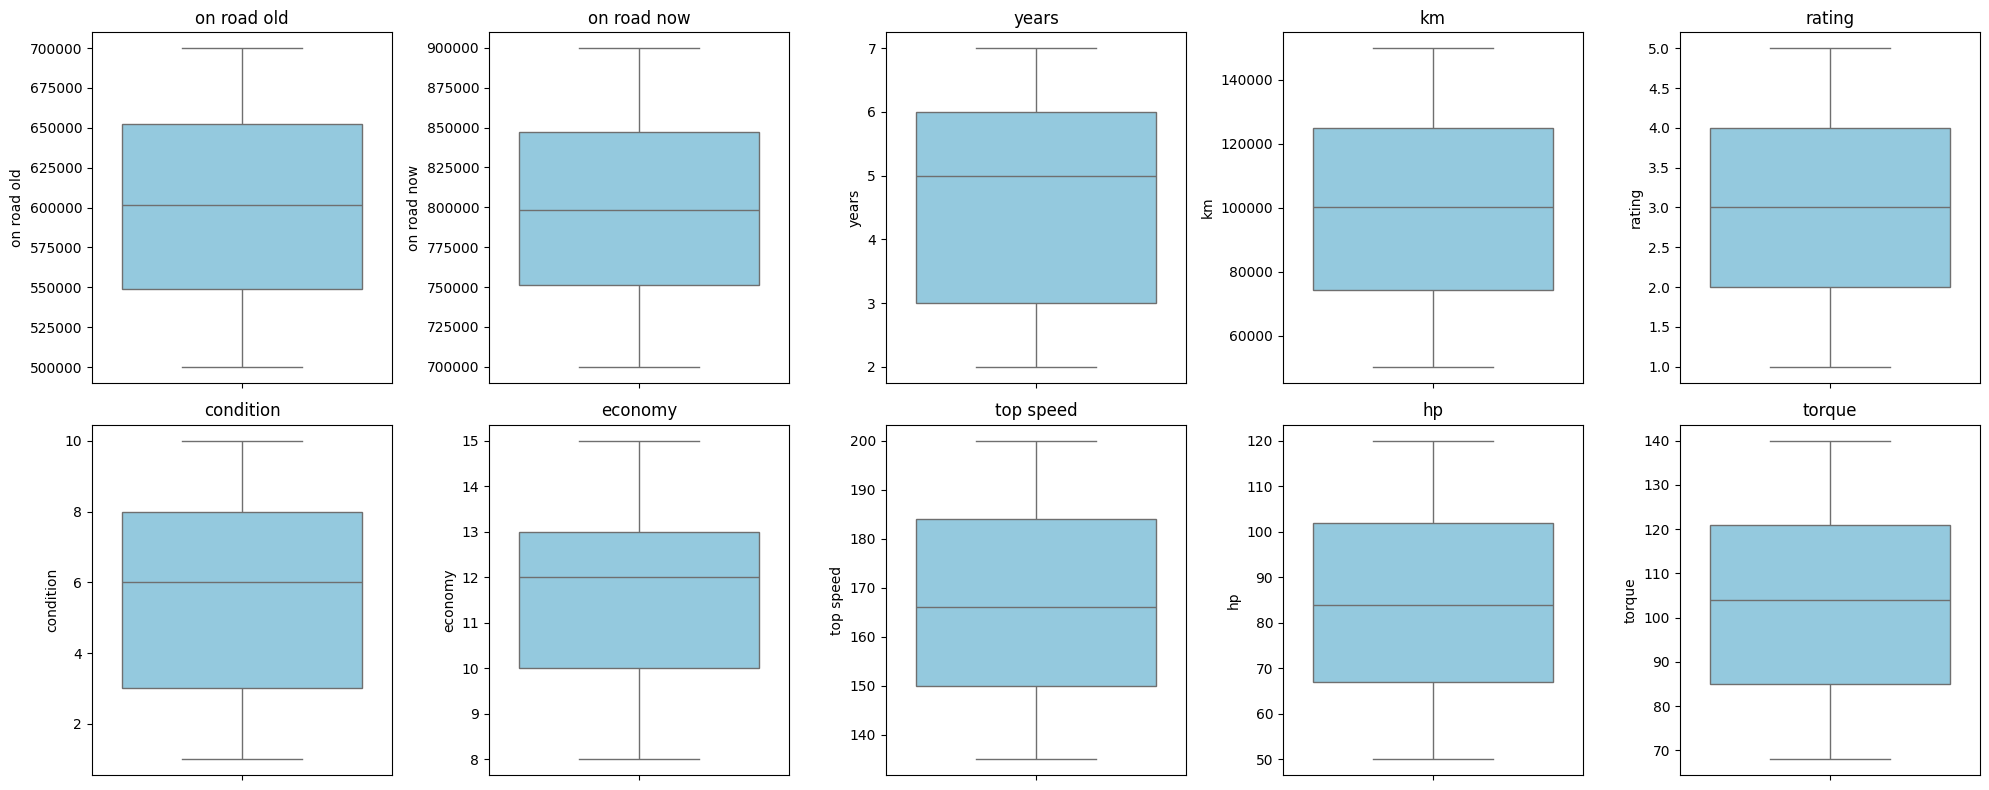

In [ ]:
num_cols = data.drop(columns=['v.id', 'current price']).columns
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=data[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

km, on read ole e now e top speed tem maior variação. Já years, rating e condition por terem poucos valores possiveis não tem muita variação(sem outliers)

Matriz de correlação com o alvo heheheheh o corr() calcula o coeficiente de correlação de Pearson, matriz quadrada de linhas e colunas com os mesmos nomes e vai de -1 a +1. Escolhemos a preço para mostrar as correlações com ele. Annot mostra numero de cada celula fmt é as casas decimais center força que o fique como branco

current price    1.000000
on road now      0.282793
on road old      0.233035
condition        0.110108
rating           0.035038
hp               0.030238
torque          -0.002290
years           -0.011854
top speed       -0.027993
economy         -0.034711
km              -0.935924
Name: current price, dtype: float64


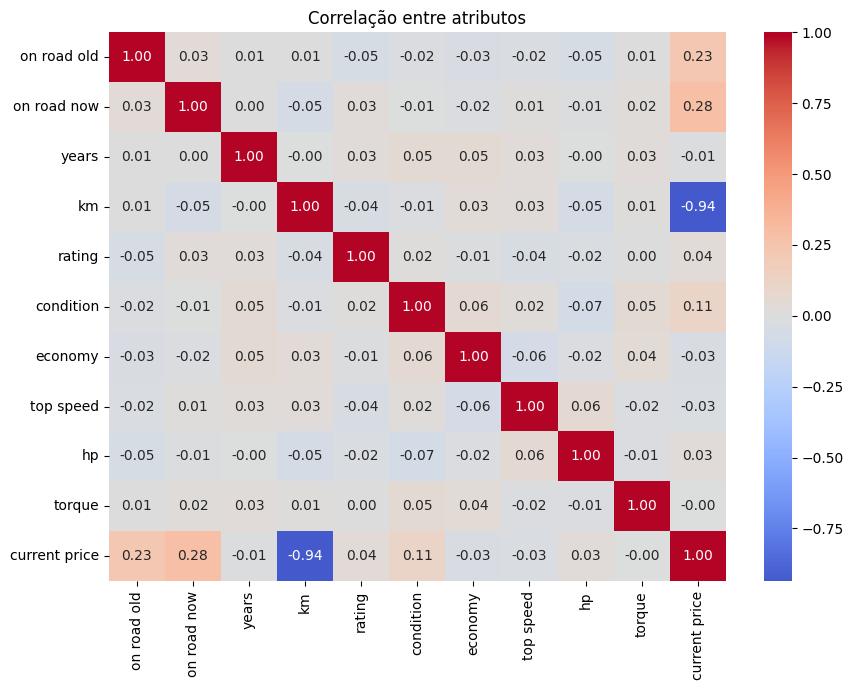

In [ ]:
corr_matrix = data.drop(columns=['v.id']).corr()
print(corr_matrix['current price'].sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre atributos")
plt.tight_layout()
plt.show()

 km tem correlação negativa e forte com current prize - quanto mais rodado, menor o preço e on the road now e old tem correção positiva com o price.

## Etapa 3 - Separação entre treino e test - estratificação


In [ ]:
#embaralha e divide o dataset
# sklearn é quem divide
from sklearn.model_selection import train_test_split

# separa 20% para teste e guarda
#a cada 42 dados é separado a amostra teste
train_set, test_set = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)

#devolve o set de treino e o set de teste
print(f"Treino: {len(train_set)} linhas | Teste: {len(test_set)} linhas")

#elimina coluna de preço atual e o id do treinamento
X_train = train_set.drop(columns=['v.id', 'current price'])

#adiciona a coluna de preço atual para a copia do treinamento
y_train = train_set['current price'].copy()

#...do teste
X_test = test_set.drop(columns=['v.id', 'current price'])

#...do teste
y_test = test_set['current price'].copy()

Treino: 800 linhas | Teste: 200 linhas


## Etapa 4 - Análise exploratória aprofundada - APENAS NO TESTE

X_train_extra precisa ser uma cópia do X_train e não o oficial.<br/>


In [ ]:
X_train_extra = X_train.copy()

# desvalorização em relação ao preço de tabela na fábrica (quanto o carro já perdeu de valor)
X_train_extra['depreciacao'] = X_train_extra['on road old'] - X_train_extra['on road now']

# km rodados por ano de uso — separa "carro velho pouco usado" de "carro novo muito rodado"
X_train_extra['km_por_ano'] = X_train_extra['km'] / X_train_extra['years']

# cavalos de potência por torque, como proxy de perfil do motor
X_train_extra['hp_por_torque'] = X_train_extra['hp'] / X_train_extra['torque']

#cria conluna current price, ais=1 coloca as colunas lado a lado
corr_check = pd.concat([X_train_extra, y_train], axis=1)

#verifica se todas as colunas são realmente numericas
#depois filtra só a coluna current price, e a ordena crescente?
print(corr_check.corr(numeric_only=True)['current price'].sort_values(ascending=False))

current price    1.000000
on road now      0.273694
on road old      0.234771
condition        0.111200
hp               0.061127
rating           0.047479
hp_por_torque    0.042801
torque           0.017220
years           -0.008066
depreciacao     -0.026120
top speed       -0.029942
economy         -0.039360
km_por_ano      -0.466993
km              -0.933827
Name: current price, dtype: float64


Nenhum dos novos atributos superou os atributos originais, então é melhor manter eles

## Etapa 5, 6, 7 e 8- Limpeza e tratamento dos dados nulos, engenharia de atributos, codificação de variáveis categorica e codificação de variaveis categoricas


Como todos os dados são numéricos, a única coisa que precisamos é colocar tudo na mesma escala

In [ ]:
# Importa a classe que faz a padronização z-scale
from sklearn.preprocessing import StandardScaler

#Cria uma instância ainda "vazia" — sem saber média/desvio-padrão de nada ainda
scaler = StandardScaler()

#fit calcula o desvio de cada coluna segundo o z-scaler e transform aplica a formula de padronização para todas as colunas (x-médio)/desvio padrão.
X_train_scaled = scaler.fit_transform(X_train_extra)

## Etapa 8 e 9 - Escalonamento de atributos e pipeline completo de pre processamento
Empacotar tudo em um Pipeline scikit-learn para deixar o processo reprodutivel e reaplicavel para o conjunto teste

In [ ]:
#Cria uma classe que traz o BaseEstimador(dá todos os métodos que o sklearn tem como get e set) e TransformerMixin(método do fit_transform)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

#Herdar dessas duas classes é o que permite colocar AtributosDerivados() dentro de um Pipeline, lado a lado com StandardScaler e outros transformadores prontos
class AtributosDerivados(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
      #Devolve ele mesmo sem alteração
        return self

    def transform(self, X): #cria lógica com as formulas utilizadas anteriormente
        X = X.copy() #evitar que os dados originais e o X pode ser o treino ou teste
        X['depreciacao'] = X['on road old'] - X['on road now']
        X['km_por_ano'] = X['km'] / X['years']
        X['hp_por_torque'] = X['hp'] / X['torque']
        return X #devolve ele com as 3 colunas novas

full_pipeline = Pipeline([ #encadeia as transformações
    ('attribs_adder', AtributosDerivados()), #cria as colunas derivadas primeiro
    ('std_scaler', StandardScaler()), #padroniza tudo
])
#Isso é importante porque quando fizermos a amostra de teste só precisaremos utilizar a pipeline
X_train_prepared = full_pipeline.fit_transform(X_train)
print(X_train_prepared.shape)

(800, 13)


## Etapa 10, 11, 12 e 13 - Treinamento de modelos, avaliação com validação cruzada, ajuste de hiperparametros e importancia dos parametros

Treina três modelos diferentes de regressão nos mesmos dados preparados e compara o desempenho deles usando validação cruzada — é a etapa que efetivamente responde "qual desses algoritmos funciona melhor para prever o preço atual"

[Regressão Linear] RMSE médio: 8,675 | desvio-padrão: 543
[Árvore de Decisão] RMSE médio: 29,115 | desvio-padrão: 1,767
[Random Forest] RMSE médio: 18,763 | desvio-padrão: 1,377


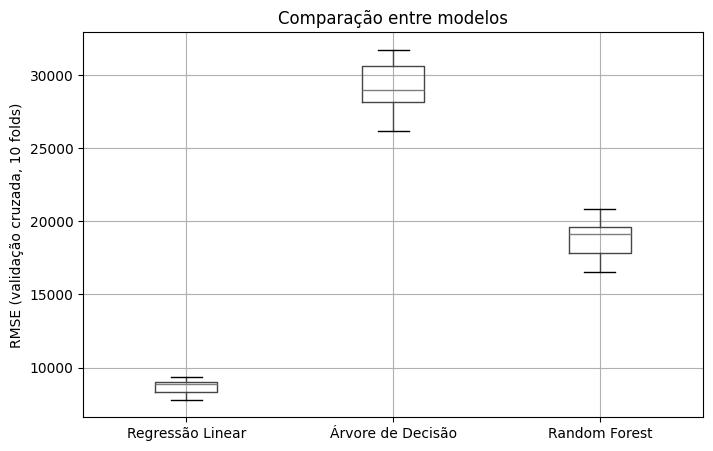

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score #função que faz a validação cruzada

modelos = {
    "Regressão Linear": LinearRegression(), #Ajusta uma reta tentando diminuir o erro quadrático
    "Árvore de Decisão": DecisionTreeRegressor(random_state=RANDOM_STATE), #sequecia de if/else que divide os dados,captura relações não lineares, porem pode ter overfitting
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), #treina 100 arvores de decisão diferentes e tira a média das previsões delas
    #n_jobs=-1 significa que usa todos os núcleos da CPU disponiveis para treinar mais rápido as arvores (em paralelo)
}

resultados = {}
for nome, modelo in modelos.items(): #percorre os itens, devolvendo os pares de nome e modelo
    #coração da validação cruzada
    scores = cross_val_score(modelo, X_train_prepared, y_train,
                              scoring='neg_mean_squared_error', cv=10) #o valor de cv significa o numero em que se divide as 800 amostras, no caso, 10 partes
                              #neg_mean_squared_error calcula em cada rodada mas em negativo
                              #a biblioteca sempre tenta maximizar a métrica de pontuação,o MSE é o erro equanto menor, melhor
                              # ele inverte o sinal para poder tratar "menos negativo" como "melhor".
    rmse_scores = np.sqrt(-scores) #o scores retorna 10 valores e o "-" inverte o valor voltando a ser positivo
    resultados[nome] = rmse_scores
    print(f"[{nome}] RMSE médio: {rmse_scores.mean():,.0f} | desvio-padrão: {rmse_scores.std():,.0f}")
                          # o quanto o valor varia de fold a fold indica estabiliadade
                          #:,.0f sem casas decimais

pd.DataFrame(resultados).boxplot(figsize=(8, 5)) #devolve um boxplot por coluna, uma por modelo
plt.ylabel("RMSE (validação cruzada, 10 folds)")
plt.title("Comparação entre modelos")
plt.show()

A Regressão Linear é disparadamente a melhor — erro médio de ~8.675 reais, contra ~18.763 do Random Forest e ~29.115 da Árvore de Decisão, o que é incomum. Porém faz sentido porque os km já explica sozinho a variação de forma linear

## Etapa 14 - Avaliação final do conjunto teste

Na prática, quanto mais "colados" na linha vermelha os pontos ficarem, melhor o modelo. E como predito na etapa 13, a Regressa Linear é o melhor dos métodos.

RMSE no teste: 8,948
MAE no teste : 7,497


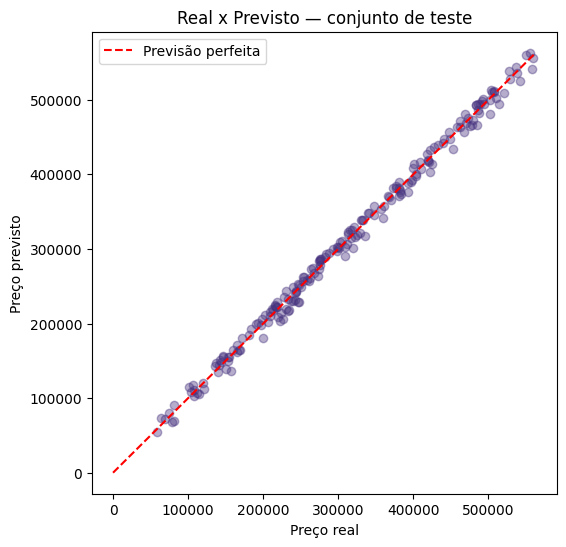

In [ ]:
melhor_modelo = LinearRegression() #não tem aleatoriedade nem paralelismo por padrão
melhor_modelo.fit(X_train_prepared, y_train)

X_test_prepared = full_pipeline.transform(X_test)
preds = melhor_modelo.predict(X_test_prepared)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
print(f"RMSE no teste: {rmse:,.0f}")
print(f"MAE no teste : {mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4) #cada ponto é um carro do teste: eixo X o preço real, eixo Y o preço previsto.
lims = [0, max(y_test.max(), preds.max())] #calcula o maior valor entre o maior preço real e a maior previsão, para desenhar uma linha de referência
plt.plot(lims, lims, 'r--', label='Previsão perfeita') #desenha a reta diagonal y = x (pontilhada, vermelha)
                                                        # se um ponto cai exatamente sobre essa linha, a previsão foi perfeita para aquele carro.
# rotulagem padrão do gráfico
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste")
plt.show()

Como um extra, também foi feito os outros dois métodos, como esperado os pontos estao mais longe da predição e a fórmula para utiliza-los é um pouco diferente.

RMSE no teste: 19,441
MAE no teste : 15,183


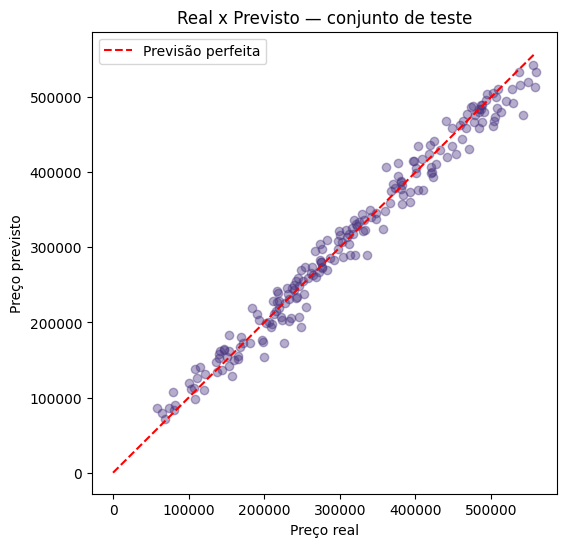

In [ ]:
# Cria uma instância nova do modelo (com os mesmos hiperparâmetros usados na comparação anterior)
# precisa de n_estimators/random_state/n_jobs, pois tem tem aleatoriedade e paralelismo por padrão
segundo_melhor_modelo = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1) #*NAO É O MELHOR*, mas para ver que precisa
segundo_melhor_modelo.fit(X_train_prepared, y_train)

X_test_prepared = full_pipeline.transform(X_test)
preds = melhor_modelo.predict(X_test_prepared)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
print(f"RMSE no teste: {rmse:,.0f}")
print(f"MAE no teste : {mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4)
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste")
plt.show()

RMSE no teste: 32,417
MAE no teste : 24,697


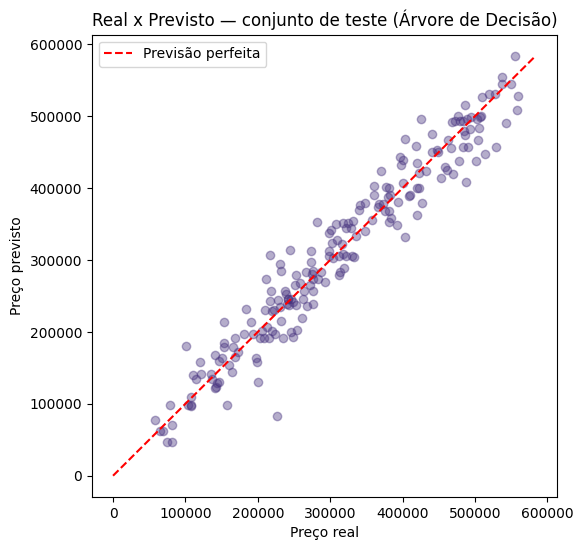

In [ ]:
from sklearn.tree import DecisionTreeRegressor

terceiro_melhor_modelo = DecisionTreeRegressor(random_state=RANDOM_STATE)
terceiro_melhor_modelo.fit(X_train_prepared, y_train)

X_test_prepared = full_pipeline.transform(X_test)
preds = melhor_modelo.predict(X_test_prepared)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
print(f"RMSE no teste: {rmse:,.0f}")
print(f"MAE no teste : {mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4)
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste (Árvore de Decisão)")
plt.show()